In [15]:
import mne
import numpy as np
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import glob

In [16]:
dataset_path = Path('/home/aloo/CNS_Summer_Project_1/Infants_data')

subjects = sorted([d for d in os.listdir(dataset_path) if d.startswith('sub-NORB')])
print(f"Found {len(subjects)} subjects")

Found 103 subjects


In [17]:
def find_edf_files(subject_id):
    """Find all EDF files for a given subject."""
    subject_path = dataset_path / subject_id
    edf_files = []
    
    if subject_path.exists():
        edf_files = list(subject_path.rglob('*.edf'))
    
    return edf_files

test_subject = subjects[68]
edf_files = find_edf_files(test_subject)
print(f"\n{test_subject}:")
print(f"  Found {len(edf_files)} EDF file(s)")
for edf in edf_files:
    print(f"  - {edf.name}")


sub-NORB00069:
  Found 4 EDF file(s)
  - sub-NORB00069_ses-2_task-EEG_eeg.edf
  - sub-NORB00069_ses-1_task-EEG_eeg.edf
  - sub-NORB00069_ses-3_task-EEG_eeg.edf
  - sub-NORB00069_ses-4_task-EEG_eeg.edf


In [18]:
def load_edf_data(edf_path):
    """
    Load EDF file with MNE and extract EEG channels.
    """
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    
    n_channels = len(raw.ch_names)
    sampling_rate = raw.info['sfreq']
    duration = raw.times[-1]
    
    print(f"\nLoaded: {Path(edf_path).name}")
    # print(f"  Channels: {n_channels}")
    # print(f"  Sampling rate: {sampling_rate} Hz")
    # print(f"  Duration: {duration:.2f} seconds")
    # print(f"  Channel names: {raw.ch_names}")
    
    return raw

if edf_files:
    raw = load_edf_data(edf_files[0])
else:
    print("No EDF files found for testing")


Loaded: sub-NORB00069_ses-2_task-EEG_eeg.edf


In [19]:
def detect_bad_channels(raw, flat_threshold=1e-12, noise_threshold=1e-2):
    """
    Detect bad channels (flat or extremely noisy).
    """
    data = raw.get_data()
    channel_names = raw.ch_names
    bad_channels = []
    
    # Define reference/ground channel names to exclude
    ref_ground_channels = {'PG1', 'PG2', 'REF', 'GND', 'GROUND', '25+', '26+', '27+'}
    
    for i, ch_name in enumerate(channel_names):
        ch_data = data[i, :]
        ch_std = np.std(ch_data)
        ch_range = np.max(ch_data) - np.min(ch_data)
        
        is_bad = False
        
        # Check if flat
        if ch_std < flat_threshold:
            is_bad = True
        
        # Check if too noisy
        elif ch_std > noise_threshold:
            is_bad = True
        
        # Check if constant value
        elif ch_range == 0:
            is_bad = True
        
        # Check for reference/ground channels
        elif ch_name.upper() in ref_ground_channels:
            is_bad = True
        
        if is_bad:
            bad_channels.append(ch_name)
    
    # print(f"\nFound {len(bad_channels)} bad channel(s): {bad_channels}")
    
    return bad_channels

if 'raw' in locals():
    bad_channels = detect_bad_channels(raw)
    
    # Remove bad channels if any found
    if bad_channels:
        raw_clean = raw.copy()
        raw_clean.drop_channels(bad_channels)
        print(f"\nRemoved {len(bad_channels)} bad channel(s)")
        print(f"Remaining channels ({len(raw_clean.ch_names)}): {raw_clean.ch_names}")
    else:
        raw_clean = raw.copy()
        print("\nNo bad channels detected. Proceeding with all channels.")
    
    raw_filtered = raw_clean  # For compatibility with downstream code
else:
    print("Error: 'raw' data not found. Please run Step 1 first.")


No bad channels detected. Proceeding with all channels.


In [20]:
def load_annotations(subject_id, session_id, dataset_path):
    """
    Load annotation file for a given subject and session.
    Handles TSV files with trailing tabs/whitespace robustly.
    """
    annotations_path = dataset_path / 'derivatives' / 'NeuronicEEG' / subject_id / session_id / 'eeg' / f'{subject_id}_{session_id}_task-EEG_annotations.tsv'
    
    if annotations_path.exists():
        # Read file line by line to handle trailing tabs properly
        with open(annotations_path, 'r') as f:
            lines = f.readlines()
        
        # Parse manually to avoid pandas issues with trailing tabs
        data = []
        header = None
        
        for i, line in enumerate(lines):
            # Split by tab and strip whitespace from each field
            fields = [field.strip() for field in line.strip().split('\t')]
            
            if i == 0:
                # Header row
                header = fields[:3]  # Only take first 3 columns: onset, duration, label
            else:
                # Data row - only take first 3 fields
                if len(fields) >= 3 and fields[0] and fields[1]:  # Ensure we have onset and duration
                    try:
                        onset = float(fields[0])
                        duration = float(fields[1])
                        label = fields[2] if fields[2] else 'eyes_closed'  # Default if empty
                        data.append([onset, duration, label])
                    except ValueError:
                        continue  # Skip malformed lines
        
        if data:
            annotations_df = pd.DataFrame(data, columns=['onset', 'duration', 'label'])
            return annotations_df
        else:
            print(f"  Warning: No valid data in annotations file: {annotations_path}")
            return None
    else:
        print(f"  Warning: No annotations file found at {annotations_path}")
        return None

def segment_data_from_annotations(raw, annotations_df, label='eyes_closed'):
    """
    Segment EEG data based on annotations file.
    Only extracts segments marked with the specified label (e.g., 'eyes_closed').
    """
    sfreq = raw.info['sfreq']
    data = raw.get_data()
    n_channels, n_samples = data.shape

    # Normalize labels for robust matching
    label_lower = label.lower().strip()
    ann_labels = annotations_df['label'].fillna('').astype(str).str.lower().str.strip()

    # Second approach: only map Spanish alias when requested label is eyes_closed
    if label_lower == 'eyes_closed':
        filtered_annotations = annotations_df[
            (ann_labels == 'eyes_closed') |
            (ann_labels == 'ojos_cerrados')
        ]
    else:
        filtered_annotations = annotations_df[ann_labels == label_lower]
    
    segments = []
    segment_info = []
    
    # print(f"\nSegmenting data from annotations file...")
    # print(f"  Total annotations: {len(annotations_df)}")
    # print(f"  Unique labels found: {annotations_df['label'].unique().tolist()}")
    # print(f"  Annotations matching '{label}' {len(filtered_annotations)}")
    
    for idx, row in filtered_annotations.iterrows():
        onset = row['onset']  # in seconds
        duration = row['duration']  # in seconds
        
        # Convert to sample indices
        start_sample = int(onset * sfreq)
        end_sample = int((onset + duration) * sfreq)
        
        # Check if segment is within bounds
        if start_sample >= 0 and end_sample <= n_samples:
            segment = data[:, start_sample:end_sample]
            segments.append(segment)
            segment_info.append({
                'onset': onset,
                'duration': duration,
                'start_sample': start_sample,
                'end_sample': end_sample
            })
        else:
            print(f"  Warning: Segment at onset={onset}s exceeds data bounds, skipping")
    
    print(f"\nExtracted {len(segments)} valid segments")
    
    return segments, segment_info

# Apply segmentation based on annotations
if 'raw_clean' in locals():
    # Extract subject and session info from the loaded EDF file
    if 'edf_files' in locals() and edf_files:
        edf_name = edf_files[0].stem
        parts = edf_name.split('_')
        subject_id = parts[0]  # e.g., 'sub-NORB00042'
        session_id = parts[1] if len(parts) > 1 and 'ses' in parts[1] else 'ses-1'
        
        # Load annotations
        annotations_df = load_annotations(subject_id, session_id, dataset_path)
        
        if annotations_df is not None:
            # Segment data based on annotations
            segments, segment_info = segment_data_from_annotations(raw_clean, annotations_df, label='eyes_closed')
            
            if len(segments) > 0:
                print(f"\n✓ Successfully segmented data for {subject_id} {session_id}")
            else:
                print(f"\n⚠ No valid segments found for {subject_id} {session_id}")
        else:
            print(f"\n⚠ Could not load annotations. Skipping segmentation.")
    else:
        print("Error: EDF file information not found.")
else:
    print("Error: 'raw_clean' data not found. Please run bad channel detection first.")


Extracted 20 valid segments

✓ Successfully segmented data for sub-NORB00069 ses-2


In [21]:
def compute_segment_pearson_matrices(segments, expected_n_channels=19, channel_names=None, strict=True):
    """
    Compute a Pearson correlation matrix for each EEG segment.

    Parameters
    ----------
    segments : list[np.ndarray]
        Each segment must have shape (n_channels, n_samples).
    expected_n_channels : int, default=19
        Expected number of EEG channels.
    channel_names : list[str] | None
        Optional channel labels for DataFrame output.
    strict : bool, default=True
        If True, raise an error when a segment does not match expected channels.
        If False, skip incompatible segments.

    Returns
    -------
    corr_matrices : np.ndarray
        Array with shape (n_valid_segments, n_channels, n_channels).
    matrix_dfs : list[pd.DataFrame]
        Correlation matrices as DataFrames (useful for export/inspection).
    skipped_segments : list[int]
        Indices of segments skipped due to shape mismatch or invalid samples.
    """
    corr_matrices = []
    matrix_dfs = []
    skipped_segments = []

    for seg_idx, seg in enumerate(segments):
        seg = np.asarray(seg)

        if seg.ndim != 2:
            if strict:
                raise ValueError(f"Segment {seg_idx} must be 2D (channels x samples). Got shape {seg.shape}.")
            skipped_segments.append(seg_idx)
            continue

        n_channels, n_samples = seg.shape

        if n_channels != expected_n_channels:
            msg = (
                f"Segment {seg_idx} has {n_channels} channels, "
                f"expected {expected_n_channels}."
            )
            if strict:
                raise ValueError(msg)
            skipped_segments.append(seg_idx)
            continue

        if n_samples < 2:
            if strict:
                raise ValueError(f"Segment {seg_idx} has fewer than 2 samples.")
            skipped_segments.append(seg_idx)
            continue

        corr = np.corrcoef(seg)

        # Replace NaNs from constant channels with 0; diagonal stays 1.
        corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
        np.fill_diagonal(corr, 1.0)

        corr_matrices.append(corr)

        if channel_names is not None and len(channel_names) == expected_n_channels:
            matrix_dfs.append(pd.DataFrame(corr, index=channel_names, columns=channel_names))
        else:
            matrix_dfs.append(pd.DataFrame(corr))

    if len(corr_matrices) == 0:
        empty = np.empty((0, expected_n_channels, expected_n_channels))
        return empty, matrix_dfs, skipped_segments

    corr_matrices = np.stack(corr_matrices, axis=0)
    return corr_matrices, matrix_dfs, skipped_segments


# Example usage with your segmented session data
if 'segments' in locals() and len(segments) > 0:
    ch_names = raw_clean.ch_names if 'raw_clean' in locals() else None

    segment_corr_matrices, segment_corr_dfs, skipped = compute_segment_pearson_matrices(
        segments,
        expected_n_channels=19,
        channel_names=ch_names,
        strict=False
    )

    print(f"Computed correlation matrices: {segment_corr_matrices.shape}")
    print(f"Skipped segments: {len(skipped)}")

    if segment_corr_matrices.shape[0] > 0:
        print("First segment matrix shape:", segment_corr_matrices[0].shape)
else:
    print("No segments available. Run segmentation first.")

Computed correlation matrices: (20, 19, 19)
Skipped segments: 0
First segment matrix shape: (19, 19)


In [22]:
def compute_node_weights_from_corr_matrices(corr_matrices, channel_names=None, normalize_by_others=True):
    """
    Compute one weight per node from segment-wise correlation matrices.

    Weight definition per node i (for each segment):
        weight_i = sum_j(|r_ij|, j != i) / divisor

    By default, divisor = (n_nodes - 1), which keeps weights in [0, 1].

    Parameters
    ----------
    corr_matrices : np.ndarray
        Shape: (n_segments, n_nodes, n_nodes)
    channel_names : list[str] | None
        Optional node labels for DataFrame output.
    normalize_by_others : bool, default=True
        True  -> divide by (n_nodes - 1)
        False -> divide by n_nodes

    Returns
    -------
    node_weights : np.ndarray
        Shape: (n_segments, n_nodes)
    node_weights_df : pd.DataFrame
        Rows = segments, columns = nodes.
    """
    corr_matrices = np.asarray(corr_matrices)

    if corr_matrices.ndim != 3:
        raise ValueError(
            f"corr_matrices must be 3D (n_segments, n_nodes, n_nodes). Got shape {corr_matrices.shape}."
        )

    n_segments, n_nodes, n_nodes_2 = corr_matrices.shape
    if n_nodes != n_nodes_2:
        raise ValueError("Each correlation matrix must be square.")

    abs_corr = np.abs(corr_matrices)

    # Remove self-correlation so each node uses only connections to other nodes.
    diag_idx = np.arange(n_nodes)
    abs_corr[:, diag_idx, diag_idx] = 0.0

    divisor = (n_nodes - 1) if normalize_by_others else n_nodes
    if divisor <= 0:
        raise ValueError("Invalid divisor. Number of nodes must be > 1.")

    node_weights = abs_corr.sum(axis=2) / divisor

    if channel_names is not None and len(channel_names) == n_nodes:
        node_weights_df = pd.DataFrame(node_weights, columns=channel_names)
    else:
        node_weights_df = pd.DataFrame(node_weights)

    return node_weights, node_weights_df


# Example usage with computed segment correlation matrices
if 'segment_corr_matrices' in locals() and segment_corr_matrices.shape[0] > 0:
    ch_names = raw_clean.ch_names if 'raw_clean' in locals() else None

    segment_node_weights, segment_node_weights_df = compute_node_weights_from_corr_matrices(
        segment_corr_matrices,
        channel_names=ch_names,
        normalize_by_others=True
    )

    print(f"Node weights array shape: {segment_node_weights.shape}")
    print("First segment node weights:")
    print(segment_node_weights_df.iloc[0])
else:
    print("No segment correlation matrices found. Run the previous cell first.")

Node weights array shape: (20, 19)
First segment node weights:
Fp1    0.743794
Fp2    0.734716
F3     0.737914
F4     0.719806
C3     0.680742
C4     0.696366
P3     0.670348
P4     0.632692
O1     0.494773
O2     0.619578
F7     0.744039
F8     0.734944
T3     0.628051
T4     0.722940
T5     0.418704
T6     0.550983
FZ     0.666194
CZ     0.639058
PZ     0.684285
Name: 0, dtype: float64


In [23]:
def compute_session_node_weights(segment_node_weights, channel_names=None):
    """
    Aggregate segment-wise node weights into one session-level weight per node.

    Parameters
    ----------
    segment_node_weights : np.ndarray
        Shape: (n_segments, n_nodes)
    channel_names : list[str] | None
        Optional node labels.

    Returns
    -------
    session_node_weights : np.ndarray
        Shape: (n_nodes,)
    session_node_weights_df : pd.DataFrame
        Single-row DataFrame with one value per node for the session.
    """
    segment_node_weights = np.asarray(segment_node_weights)

    if segment_node_weights.ndim != 2:
        raise ValueError(
            f"segment_node_weights must be 2D (n_segments, n_nodes). Got shape {segment_node_weights.shape}."
        )

    n_segments, n_nodes = segment_node_weights.shape
    if n_segments == 0:
        raise ValueError("No segments available to aggregate.")

    # Mean across segments: sum over segments divided by number of segments.
    session_node_weights = segment_node_weights.sum(axis=0) / n_segments

    if channel_names is not None and len(channel_names) == n_nodes:
        session_node_weights_df = pd.DataFrame([session_node_weights], columns=channel_names)
    else:
        session_node_weights_df = pd.DataFrame([session_node_weights])

    return session_node_weights, session_node_weights_df


# Example usage: one value per node for the full session
if 'segment_node_weights' in locals() and segment_node_weights.shape[0] > 0:
    ch_names = raw_clean.ch_names if 'raw_clean' in locals() else None

    session_node_weights, session_node_weights_df = compute_session_node_weights(
        segment_node_weights,
        channel_names=ch_names
    )

    print(f"Session node weights shape: {session_node_weights.shape}")
    print("Session-level weight per node:")
    print(session_node_weights_df.iloc[0])
else:
    print("No segment node weights found. Run the previous cell first.")

Session node weights shape: (19,)
Session-level weight per node:
Fp1    0.477695
Fp2    0.481448
F3     0.493291
F4     0.501927
C3     0.468566
C4     0.477515
P3     0.434452
P4     0.426779
O1     0.290306
O2     0.417846
F7     0.463304
F8     0.487190
T3     0.353536
T4     0.384929
T5     0.296779
T6     0.309337
FZ     0.465050
CZ     0.418267
PZ     0.452320
Name: 0, dtype: float64


In [24]:
SESSION_META_COLUMNS = ('subject_id', 'session_id', 'n_segments')


def _extract_subject_session_from_edf_name(edf_path):
    """Extract subject_id and session_id from an EDF filename."""
    stem = Path(edf_path).stem
    parts = stem.split('_')

    subject_id = parts[0] if parts else None
    session_id = next((part for part in parts if part.startswith('ses-')), 'ses-1')

    return subject_id, session_id


def _session_sort_key(session_id):
    """Sort helper so ses-10 comes after ses-9 (numeric ordering)."""
    try:
        return int(str(session_id).split('-')[-1])
    except (ValueError, TypeError):
        return str(session_id)


def _load_and_clean_raw(edf_path):
    """Load EDF and remove detected bad channels."""
    raw = load_edf_data(edf_path)
    bad_channels = detect_bad_channels(raw)

    raw_clean = raw.copy()
    if bad_channels:
        raw_clean.drop_channels(bad_channels)

    return raw_clean


def _build_session_row(subject_id, session_id, n_segments, channel_names, session_node_weights):
    """Build one output row for session-level node weights."""
    row = {
        'subject_id': subject_id,
        'session_id': session_id,
        'n_segments': int(n_segments)
    }

    for ch_idx, ch_name in enumerate(channel_names):
        row[ch_name] = float(session_node_weights[ch_idx])

    return row


def compute_session_node_weights_for_subject(subject_id, dataset_path, label='eyes_closed', expected_n_channels=19):
    """
    Compute one node-weight vector per session for a subject.

    Pipeline per session:
    EDF -> bad channel removal -> annotation-based segmentation ->
    segment correlation matrices -> segment node weights -> session node weights
    """
    subject_path = Path(dataset_path) / subject_id
    edf_files = sorted(subject_path.rglob('*.edf'))

    if len(edf_files) == 0:
        raise ValueError(f"No EDF files found for subject {subject_id}.")

    session_rows = []

    for edf_path in edf_files:
        sub_id, ses_id = _extract_subject_session_from_edf_name(edf_path)
        raw_clean = _load_and_clean_raw(edf_path)

        if len(raw_clean.ch_names) != expected_n_channels:
            print(
                f"Skipping {sub_id} {ses_id}: channel count after cleaning is "
                f"{len(raw_clean.ch_names)} (expected {expected_n_channels})."
            )
            continue

        annotations_df = load_annotations(sub_id, ses_id, dataset_path)
        if annotations_df is None:
            print(f"Skipping {sub_id} {ses_id}: annotations not found.")
            continue

        segments, _ = segment_data_from_annotations(raw_clean, annotations_df, label=label)
        if len(segments) == 0:
            print(f"Skipping {sub_id} {ses_id}: no valid segments.")
            continue

        segment_corr_matrices, _, _ = compute_segment_pearson_matrices(
            segments,
            expected_n_channels=expected_n_channels,
            channel_names=raw_clean.ch_names,
            strict=False
        )

        if segment_corr_matrices.shape[0] == 0:
            print(f"Skipping {sub_id} {ses_id}: no valid correlation matrices.")
            continue

        segment_node_weights, _ = compute_node_weights_from_corr_matrices(
            segment_corr_matrices,
            channel_names=raw_clean.ch_names,
            normalize_by_others=True
        )

        session_node_weights, _ = compute_session_node_weights(
            segment_node_weights,
            channel_names=raw_clean.ch_names
        )

        session_rows.append(
            _build_session_row(
                subject_id=sub_id,
                session_id=ses_id,
                n_segments=segment_corr_matrices.shape[0],
                channel_names=raw_clean.ch_names,
                session_node_weights=session_node_weights
            )
        )

    if len(session_rows) == 0:
        raise ValueError(f"No valid sessions processed for subject {subject_id}.")

    session_node_weights_df = pd.DataFrame(session_rows)
    session_node_weights_df = session_node_weights_df.sort_values(
        by='session_id',
        key=lambda s: s.map(_session_sort_key)
    ).reset_index(drop=True)
    return session_node_weights_df


def compute_node_jaccard_across_sessions(session_node_weights_df, node_columns=None):
    """
    Compute per-node Jaccard-like stability index across sessions: min/max.

    For each node:
        J = min(session_values) / max(session_values)
    """
    if node_columns is None:
        node_columns = [
            column for column in session_node_weights_df.columns
            if column not in SESSION_META_COLUMNS
        ]

    jaccard_rows = []
    for node in node_columns:
        values = session_node_weights_df[node].astype(float).to_numpy()
        min_value = float(np.min(values))
        max_value = float(np.max(values))
        jaccard = 0.0 if max_value == 0.0 else (min_value / max_value)

        jaccard_rows.append({
            'node': node,
            'min_value': min_value,
            'max_value': max_value,
            'jaccard_min_over_max': jaccard
        })

    return pd.DataFrame(jaccard_rows)


def compute_node_jaccard_between_consecutive_sessions(session_node_weights_df, node_columns=None):
    """
    Compute node-wise Jaccard (min/max) for consecutive session pairs.

    Example pairs: ses-1 vs ses-2, ses-2 vs ses-3, ses-3 vs ses-4.
    """
    if node_columns is None:
        node_columns = [
            column for column in session_node_weights_df.columns
            if column not in SESSION_META_COLUMNS
        ]

    ordered_df = session_node_weights_df.sort_values(
        by='session_id',
        key=lambda s: s.map(_session_sort_key)
    ).reset_index(drop=True)

    if len(ordered_df) < 2:
        raise ValueError('Need at least 2 sessions to compute pairwise consecutive Jaccard.')

    pairwise_rows = []

    for i in range(len(ordered_df) - 1):
        left = ordered_df.iloc[i]
        right = ordered_df.iloc[i + 1]

        left_session = left['session_id']
        right_session = right['session_id']

        for node in node_columns:
            v1 = float(left[node])
            v2 = float(right[node])
            v_min = min(v1, v2)
            v_max = max(v1, v2)
            jaccard = 0.0 if v_max == 0.0 else (v_min / v_max)

            pairwise_rows.append({
                'subject_id': left['subject_id'],
                'session_left': left_session,
                'session_right': right_session,
                'node': node,
                'left_value': v1,
                'right_value': v2,
                'jaccard_min_over_max': jaccard
            })

    return pd.DataFrame(pairwise_rows)


def run_subject_node_jaccard_pipeline(subject_id, dataset_path, label='eyes_closed', expected_n_channels=19):
    """Run all tasks for one subject and return reusable outputs."""
    session_node_weights_df = compute_session_node_weights_for_subject(
        subject_id=subject_id,
        dataset_path=dataset_path,
        label=label,
        expected_n_channels=expected_n_channels
    )

    node_jaccard_df = compute_node_jaccard_across_sessions(session_node_weights_df)
    node_pairwise_jaccard_df = compute_node_jaccard_between_consecutive_sessions(session_node_weights_df)
    return session_node_weights_df, node_jaccard_df, node_pairwise_jaccard_df


def print_subject_pipeline_summary(
    subject_id,
    session_node_weights_df,
    node_jaccard_df,
    node_pairwise_jaccard_df,
    preview_rows=5
):
    """Print a standard summary for pipeline outputs."""
    print(f"Processed sessions for {subject_id}: {len(session_node_weights_df)}")
    print("Session-level node weights (first rows):")
    print(session_node_weights_df.head(preview_rows))

    print("\nNode-wise Jaccard across all sessions (min/max):")
    print(node_jaccard_df)

    print("\nNode-wise Jaccard between consecutive sessions (all pairs):")
    print(node_pairwise_jaccard_df)


# Example usage for one subject (all sessions)
subject_to_analyze = subjects[68]

(
    session_node_weights_all_df,
    node_jaccard_across_sessions_df,
    node_pairwise_jaccard_df
) = run_subject_node_jaccard_pipeline(
    subject_id=subject_to_analyze,
    dataset_path=dataset_path,
    label='eyes_closed',
    expected_n_channels=19
)

print_subject_pipeline_summary(
    subject_id=subject_to_analyze,
    session_node_weights_df=session_node_weights_all_df,
    node_jaccard_df=node_jaccard_across_sessions_df,
    node_pairwise_jaccard_df=node_pairwise_jaccard_df,
    preview_rows=5
)


Loaded: sub-NORB00069_ses-1_task-EEG_eeg.edf



Extracted 15 valid segments

Loaded: sub-NORB00069_ses-2_task-EEG_eeg.edf

Extracted 20 valid segments

Loaded: sub-NORB00069_ses-3_task-EEG_eeg.edf

Extracted 20 valid segments

Loaded: sub-NORB00069_ses-4_task-EEG_eeg.edf

Extracted 15 valid segments
Processed sessions for sub-NORB00069: 4
Session-level node weights (first rows):
      subject_id session_id  n_segments       Fp1       Fp2        F3  \
0  sub-NORB00069      ses-1          15  0.542079  0.534130  0.548204   
1  sub-NORB00069      ses-2          20  0.477695  0.481448  0.493291   
2  sub-NORB00069      ses-3          20  0.418922  0.444847  0.435384   
3  sub-NORB00069      ses-4          15  0.352081  0.347409  0.161324   

         F4        C3        C4        P3  ...        O2        F7        F8  \
0  0.550526  0.548164  0.551894  0.485583  ...  0.456521  0.525415  0.519372   
1  0.501927  0.468566  0.477515  0.434452  ...  0.417846  0.463304  0.487190   
2  0.471040  0.433536  0.413560  0.395905  ...  0.322041  0

In [25]:
# Compact all-pairs view
if 'node_pairwise_jaccard_df' in locals():
    display_cols = ['session_left', 'session_right', 'node', 'jaccard_min_over_max']
    pairwise_compact_df = node_pairwise_jaccard_df[display_cols].copy()

    print('Consecutive session pairs found:')
    for left_s, right_s in pairwise_compact_df[['session_left', 'session_right']].drop_duplicates().itertuples(index=False):
        print(f'  {left_s} vs {right_s}')

    print(f"\nTotal rows: {len(pairwise_compact_df)}")
    print(pairwise_compact_df.to_string(index=False))
else:
    print('Run the pipeline cell first to generate pairwise Jaccard values.')

Consecutive session pairs found:
  ses-1 vs ses-2
  ses-2 vs ses-3
  ses-3 vs ses-4

Total rows: 57
session_left session_right node  jaccard_min_over_max
       ses-1         ses-2  Fp1              0.881229
       ses-1         ses-2  Fp2              0.901368
       ses-1         ses-2   F3              0.899831
       ses-1         ses-2   F4              0.911723
       ses-1         ses-2   C3              0.854791
       ses-1         ses-2   C4              0.865230
       ses-1         ses-2   P3              0.894700
       ses-1         ses-2   P4              0.793282
       ses-1         ses-2   O1              0.649083
       ses-1         ses-2   O2              0.915281
       ses-1         ses-2   F7              0.881787
       ses-1         ses-2   F8              0.938036
       ses-1         ses-2   T3              0.748588
       ses-1         ses-2   T4              0.837175
       ses-1         ses-2   T5              0.903305
       ses-1         ses-2   T6     

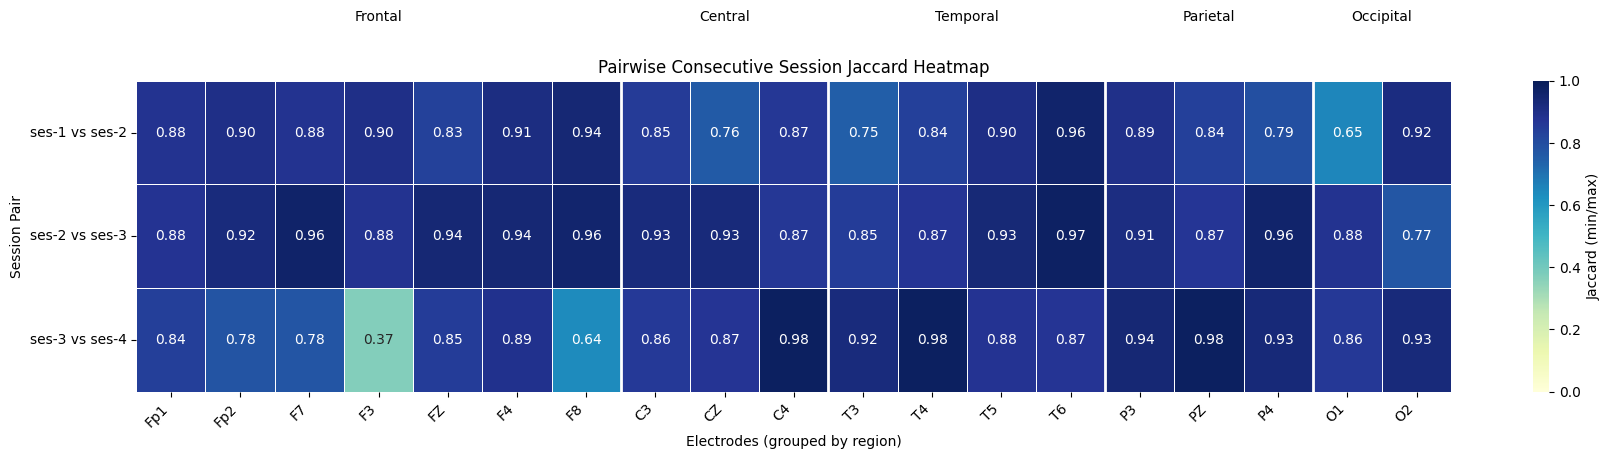

In [26]:
# Heatmap visualization for pairwise node Jaccard (combined graph only)
if 'node_pairwise_jaccard_df' in locals() and len(node_pairwise_jaccard_df) > 0:
    region_order = {
        'Frontal': ['Fp1', 'Fp2', 'F7', 'F3', 'FZ', 'F4', 'F8'],
        'Central': ['C3', 'CZ', 'C4'],
        'Temporal': ['T3', 'T4', 'T5', 'T6'],
        'Parietal': ['P3', 'PZ', 'P4'],
        'Occipital': ['O1', 'O2']
    }

    electrode_order = [el for group in region_order.values() for el in group]

    heat_df = node_pairwise_jaccard_df.copy()
    heat_df = heat_df[heat_df['node'].isin(electrode_order)].copy()
    heat_df['pair'] = heat_df['session_left'].astype(str) + ' vs ' + heat_df['session_right'].astype(str)

    # Keep pair order consistent with session numbering.
    ordered_pairs = (
        heat_df[['session_left', 'session_right', 'pair']]
        .drop_duplicates()
        .sort_values(by=['session_left', 'session_right'], key=lambda s: s.map(_session_sort_key))
    )['pair'].tolist()

    pairwise_matrix = heat_df.pivot_table(
        index='pair',
        columns='node',
        values='jaccard_min_over_max',
        aggfunc='mean'
    ).reindex(index=ordered_pairs, columns=electrode_order)

    plt.figure(figsize=(18, 4.8))
    sns.heatmap(
        pairwise_matrix,
        cmap='YlGnBu',
        vmin=0,
        vmax=1,
        annot=True,
        fmt='.2f',
        linewidths=0.5,
        cbar_kws={'label': 'Jaccard (min/max)'}
    )

    # Region separators and labels on combined heatmap.
    boundaries = np.cumsum([len(v) for v in region_order.values()])[:-1]
    for b in boundaries:
        plt.axvline(b, color='white', linewidth=2)

    start = 0
    y_text = -0.55  # place labels above x-axis ticks
    for region, electrodes in region_order.items():
        center = start + len(electrodes) / 2
        plt.text(center, y_text, region, ha='center', va='bottom', fontsize=10)
        start += len(electrodes)

    plt.title('Pairwise Consecutive Session Jaccard Heatmap')
    plt.xlabel('Electrodes (grouped by region)')
    plt.ylabel('Session Pair')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print('Run the pipeline cell first to generate pairwise Jaccard values.')

In [27]:
# Run the same pipeline for all subjects with multiple sessions

def _get_subject_session_ids(subject_id, dataset_path):
    """Return sorted unique session IDs found in EDF filenames for a subject."""
    subject_path = Path(dataset_path) / subject_id
    edf_files = sorted(subject_path.rglob('*.edf'))

    session_ids = []
    for edf_path in edf_files:
        _, ses_id = _extract_subject_session_from_edf_name(edf_path)
        session_ids.append(ses_id)

    session_ids = sorted(set(session_ids), key=_session_sort_key)
    return session_ids


multi_session_subjects = []
for subj in subjects:
    ses_ids = _get_subject_session_ids(subj, dataset_path)
    if len(ses_ids) >= 2:
        multi_session_subjects.append(subj)

print(f"Subjects with >=2 sessions: {len(multi_session_subjects)}")

all_session_weights = []
all_node_jaccard = []
all_pairwise_jaccard = []
run_failures = []

for i, subj in enumerate(multi_session_subjects, start=1):
    print(f"[{i}/{len(multi_session_subjects)}] Processing {subj}...")
    try:
        session_df, node_j_df, pairwise_df = run_subject_node_jaccard_pipeline(
            subject_id=subj,
            dataset_path=dataset_path,
            label='eyes_closed',
            expected_n_channels=19
        )

        all_session_weights.append(session_df)
        all_node_jaccard.append(node_j_df.assign(subject_id=subj))
        all_pairwise_jaccard.append(pairwise_df)

    except Exception as exc:
        run_failures.append({'subject_id': subj, 'error': str(exc)})
        print(f"  Failed for {subj}: {exc}")

all_session_weights_df = pd.concat(all_session_weights, ignore_index=True) if all_session_weights else pd.DataFrame()
all_node_jaccard_df = pd.concat(all_node_jaccard, ignore_index=True) if all_node_jaccard else pd.DataFrame()
all_pairwise_jaccard_df = pd.concat(all_pairwise_jaccard, ignore_index=True) if all_pairwise_jaccard else pd.DataFrame()
failures_df = pd.DataFrame(run_failures)

print("\nBatch run complete.")
print(f"Successful subjects: {len(all_session_weights)}")
print(f"Failed subjects: {len(run_failures)}")
print(f"all_session_weights_df shape: {all_session_weights_df.shape}")
print(f"all_node_jaccard_df shape: {all_node_jaccard_df.shape}")
print(f"all_pairwise_jaccard_df shape: {all_pairwise_jaccard_df.shape}")

if len(run_failures) > 0:
    print("\nFailures:")
    print(failures_df.head(20))

Subjects with >=2 sessions: 22
[1/22] Processing sub-NORB00064...

Loaded: sub-NORB00064_ses-1_task-EEG_eeg.edf

Extracted 13 valid segments

Loaded: sub-NORB00064_ses-2_task-EEG_eeg.edf

Extracted 20 valid segments

Loaded: sub-NORB00064_ses-3_task-EEG_eeg.edf

Extracted 17 valid segments
[2/22] Processing sub-NORB00065...

Loaded: sub-NORB00065_ses-1_task-EEG_eeg.edf

Extracted 20 valid segments

Loaded: sub-NORB00065_ses-2_task-EEG_eeg.edf

Extracted 20 valid segments
[3/22] Processing sub-NORB00069...

Loaded: sub-NORB00069_ses-1_task-EEG_eeg.edf

Extracted 15 valid segments

Loaded: sub-NORB00069_ses-2_task-EEG_eeg.edf

Extracted 20 valid segments

Loaded: sub-NORB00069_ses-3_task-EEG_eeg.edf

Extracted 20 valid segments

Loaded: sub-NORB00069_ses-4_task-EEG_eeg.edf

Extracted 15 valid segments
[4/22] Processing sub-NORB00070...

Loaded: sub-NORB00070_ses-1_task-EEG_eeg.edf

Extracted 15 valid segments

Loaded: sub-NORB00070_ses-2_task-EEG_eeg.edf

Extracted 20 valid segments

Loa

In [28]:
# Save tables and pairwise heatmaps for all processed subjects

if 'all_session_weights_df' in locals() and 'all_pairwise_jaccard_df' in locals():
    output_root = Path('/home/aloo/CNS_Summer_Project_1/Multi_Session_Jaccard_Output/node_weighted_jaccard')
    tables_dir = output_root / 'tables'
    heatmaps_dir = output_root / 'heatmaps_by_subject'

    tables_dir.mkdir(parents=True, exist_ok=True)
    heatmaps_dir.mkdir(parents=True, exist_ok=True)

    # Save aggregate tables
    all_session_weights_path = tables_dir / 'all_session_weights.csv'
    all_node_jaccard_path = tables_dir / 'all_node_jaccard_across_sessions.csv'
    all_pairwise_jaccard_path = tables_dir / 'all_pairwise_jaccard_consecutive_sessions.csv'
    failures_path = tables_dir / 'pipeline_failures.csv'

    all_session_weights_df.to_csv(all_session_weights_path, index=False)
    all_node_jaccard_df.to_csv(all_node_jaccard_path, index=False)
    all_pairwise_jaccard_df.to_csv(all_pairwise_jaccard_path, index=False)

    if 'failures_df' in locals():
        failures_df.to_csv(failures_path, index=False)
    else:
        pd.DataFrame(columns=['subject_id', 'error']).to_csv(failures_path, index=False)

    # Heatmap settings
    region_order = {
        'Frontal': ['Fp1', 'Fp2', 'F7', 'F3', 'FZ', 'F4', 'F8'],
        'Central': ['C3', 'CZ', 'C4'],
        'Temporal': ['T3', 'T4', 'T5', 'T6'],
        'Parietal': ['P3', 'PZ', 'P4'],
        'Occipital': ['O1', 'O2']
    }
    electrode_order = [el for group in region_order.values() for el in group]

    subject_ids = sorted(all_pairwise_jaccard_df['subject_id'].dropna().unique().tolist())
    saved_heatmaps = []

    for subj in subject_ids:
        subj_df = all_pairwise_jaccard_df[all_pairwise_jaccard_df['subject_id'] == subj].copy()
        if len(subj_df) == 0:
            continue

        subj_df = subj_df[subj_df['node'].isin(electrode_order)].copy()
        subj_df['pair'] = subj_df['session_left'].astype(str) + ' vs ' + subj_df['session_right'].astype(str)

        ordered_pairs = (
            subj_df[['session_left', 'session_right', 'pair']]
            .drop_duplicates()
            .sort_values(by=['session_left', 'session_right'], key=lambda s: s.map(_session_sort_key))
        )['pair'].tolist()

        pairwise_matrix = subj_df.pivot_table(
            index='pair',
            columns='node',
            values='jaccard_min_over_max',
            aggfunc='mean'
        ).reindex(index=ordered_pairs, columns=electrode_order)

        if pairwise_matrix.shape[0] == 0:
            continue

        fig_height = max(3.5, 1.4 * pairwise_matrix.shape[0] + 1.2)
        plt.figure(figsize=(18, fig_height))
        sns.heatmap(
            pairwise_matrix,
            cmap='YlGnBu',
            vmin=0,
            vmax=1,
            annot=True,
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={'label': 'Jaccard (min/max)'}
        )

        boundaries = np.cumsum([len(v) for v in region_order.values()])[:-1]
        for b in boundaries:
            plt.axvline(b, color='white', linewidth=2)

        start = 0
        y_text = -0.55
        for region, electrodes in region_order.items():
            center = start + len(electrodes) / 2
            plt.text(center, y_text, region, ha='center', va='bottom', fontsize=10)
            start += len(electrodes)

        plt.title(f'Pairwise Consecutive Session Jaccard Heatmap - {subj}')
        plt.xlabel('Electrodes (grouped by region)')
        plt.ylabel('Session Pair')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()

        heatmap_path = heatmaps_dir / f'{subj}_pairwise_jaccard_heatmap.png'
        plt.savefig(heatmap_path, dpi=200, bbox_inches='tight')
        plt.close()

        saved_heatmaps.append(str(heatmap_path))

    print('Saved tables:')
    print(f'  - {all_session_weights_path}')
    print(f'  - {all_node_jaccard_path}')
    print(f'  - {all_pairwise_jaccard_path}')
    print(f'  - {failures_path}')
    print(f'\nSaved heatmaps: {len(saved_heatmaps)}')
    if len(saved_heatmaps) > 0:
        print('Example heatmap files:')
        for p in saved_heatmaps[:5]:
            print(f'  - {p}')
else:
    print('Run the batch pipeline cell first to generate aggregate dataframes.')

Saved tables:
  - /home/aloo/CNS_Summer_Project_1/Multi_Session_Jaccard_Output/node_weighted_jaccard/tables/all_session_weights.csv
  - /home/aloo/CNS_Summer_Project_1/Multi_Session_Jaccard_Output/node_weighted_jaccard/tables/all_node_jaccard_across_sessions.csv
  - /home/aloo/CNS_Summer_Project_1/Multi_Session_Jaccard_Output/node_weighted_jaccard/tables/all_pairwise_jaccard_consecutive_sessions.csv
  - /home/aloo/CNS_Summer_Project_1/Multi_Session_Jaccard_Output/node_weighted_jaccard/tables/pipeline_failures.csv

Saved heatmaps: 21
Example heatmap files:
  - /home/aloo/CNS_Summer_Project_1/Multi_Session_Jaccard_Output/node_weighted_jaccard/heatmaps_by_subject/sub-NORB00064_pairwise_jaccard_heatmap.png
  - /home/aloo/CNS_Summer_Project_1/Multi_Session_Jaccard_Output/node_weighted_jaccard/heatmaps_by_subject/sub-NORB00065_pairwise_jaccard_heatmap.png
  - /home/aloo/CNS_Summer_Project_1/Multi_Session_Jaccard_Output/node_weighted_jaccard/heatmaps_by_subject/sub-NORB00069_pairwise_jaccard_

In [29]:
# Phase Lag Index (PLI) pipeline for the same workflow

from scipy.signal import hilbert
from mne.filter import filter_data


def compute_segment_pli_matrices(
    segments,
    sfreq,
    expected_n_channels=19,
    channel_names=None,
    l_freq=1.0,
    h_freq=40.0,
    strict=True,
):
    """
    Compute a PLI matrix for each EEG segment.

    The signal is band-pass filtered before extracting instantaneous phase.
    PLI is then computed as |mean(sign(sin(phase_i - phase_j)))|.
    """
    pli_matrices = []
    matrix_dfs = []
    skipped_segments = []

    for seg_idx, seg in enumerate(segments):
        seg = np.asarray(seg)

        if seg.ndim != 2:
            if strict:
                raise ValueError(f"Segment {seg_idx} must be 2D (channels x samples). Got shape {seg.shape}.")
            skipped_segments.append(seg_idx)
            continue

        n_channels, n_samples = seg.shape
        if n_channels != expected_n_channels:
            msg = f"Segment {seg_idx} has {n_channels} channels, expected {expected_n_channels}."
            if strict:
                raise ValueError(msg)
            skipped_segments.append(seg_idx)
            continue

        if n_samples < 2:
            if strict:
                raise ValueError(f"Segment {seg_idx} has fewer than 2 samples.")
            skipped_segments.append(seg_idx)
            continue

        try:
            filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
        except Exception as exc:
            if strict:
                raise RuntimeError(f"Filtering failed for segment {seg_idx}: {exc}") from exc
            skipped_segments.append(seg_idx)
            continue

        analytic = hilbert(filtered, axis=1)
        phases = np.angle(analytic)

        pli = np.zeros((n_channels, n_channels), dtype=float)
        for i in range(n_channels):
            for j in range(i + 1, n_channels):
                phase_diff = phases[i] - phases[j]
                value = float(np.abs(np.mean(np.sign(np.sin(phase_diff)))))
                pli[i, j] = value
                pli[j, i] = value

        np.fill_diagonal(pli, 1.0)
        pli_matrices.append(pli)

        if channel_names is not None and len(channel_names) == expected_n_channels:
            matrix_dfs.append(pd.DataFrame(pli, index=channel_names, columns=channel_names))
        else:
            matrix_dfs.append(pd.DataFrame(pli))

    if len(pli_matrices) == 0:
        empty = np.empty((0, expected_n_channels, expected_n_channels))
        return empty, matrix_dfs, skipped_segments

    pli_matrices = np.stack(pli_matrices, axis=0)
    return pli_matrices, matrix_dfs, skipped_segments


def compute_session_node_pli_weights_for_subject(
    subject_id,
    dataset_path,
    label='eyes_closed',
    expected_n_channels=19,
    l_freq=1.0,
    h_freq=40.0,
):
    """Compute one node-weight vector per session using PLI matrices."""
    subject_path = Path(dataset_path) / subject_id
    edf_files = sorted(subject_path.rglob('*.edf'))

    if len(edf_files) == 0:
        raise ValueError(f"No EDF files found for subject {subject_id}.")

    session_rows = []

    for edf_path in edf_files:
        sub_id, ses_id = _extract_subject_session_from_edf_name(edf_path)
        raw_clean = _load_and_clean_raw(edf_path)

        if len(raw_clean.ch_names) != expected_n_channels:
            print(
                f"Skipping {sub_id} {ses_id}: channel count after cleaning is "
                f"{len(raw_clean.ch_names)} (expected {expected_n_channels})."
            )
            continue

        annotations_df = load_annotations(sub_id, ses_id, dataset_path)
        if annotations_df is None:
            print(f"Skipping {sub_id} {ses_id}: annotations not found.")
            continue

        segments, _ = segment_data_from_annotations(raw_clean, annotations_df, label=label)
        if len(segments) == 0:
            print(f"Skipping {sub_id} {ses_id}: no valid segments.")
            continue

        segment_pli_matrices, _, _ = compute_segment_pli_matrices(
            segments,
            sfreq=raw_clean.info['sfreq'],
            expected_n_channels=expected_n_channels,
            channel_names=raw_clean.ch_names,
            l_freq=l_freq,
            h_freq=h_freq,
            strict=False,
        )

        if segment_pli_matrices.shape[0] == 0:
            print(f"Skipping {sub_id} {ses_id}: no valid PLI matrices.")
            continue

        segment_node_weights, _ = compute_node_weights_from_corr_matrices(
            segment_pli_matrices,
            channel_names=raw_clean.ch_names,
            normalize_by_others=True,
        )

        session_node_weights, _ = compute_session_node_weights(
            segment_node_weights,
            channel_names=raw_clean.ch_names,
        )

        session_rows.append(
            _build_session_row(
                subject_id=sub_id,
                session_id=ses_id,
                n_segments=segment_pli_matrices.shape[0],
                channel_names=raw_clean.ch_names,
                session_node_weights=session_node_weights,
            )
        )

    if len(session_rows) == 0:
        raise ValueError(f"No valid sessions processed for subject {subject_id}.")

    session_node_weights_df = pd.DataFrame(session_rows)
    session_node_weights_df = session_node_weights_df.sort_values(
        by='session_id',
        key=lambda s: s.map(_session_sort_key),
    ).reset_index(drop=True)
    return session_node_weights_df


def run_subject_node_pli_pipeline(subject_id, dataset_path, label='eyes_closed', expected_n_channels=19, l_freq=1.0, h_freq=40.0):
    """Run all PLI tasks for one subject and return reusable outputs."""
    session_node_weights_df = compute_session_node_pli_weights_for_subject(
        subject_id=subject_id,
        dataset_path=dataset_path,
        label=label,
        expected_n_channels=expected_n_channels,
        l_freq=l_freq,
        h_freq=h_freq,
    )
    node_jaccard_df = compute_node_jaccard_across_sessions(session_node_weights_df)
    node_pairwise_jaccard_df = compute_node_jaccard_between_consecutive_sessions(session_node_weights_df)
    return session_node_weights_df, node_jaccard_df, node_pairwise_jaccard_df


# Batch run PLI pipeline for all multi-session subjects and save outputs
pli_output_root = Path('/home/aloo/CNS_Summer_Project_1/Multi_Session_Jaccard_Output/node_weighted_pli')
pli_tables_dir = pli_output_root / 'tables'
pli_heatmaps_dir = pli_output_root / 'heatmaps_by_subject'
pli_tables_dir.mkdir(parents=True, exist_ok=True)
pli_heatmaps_dir.mkdir(parents=True, exist_ok=True)

pli_session_weights = []
pli_node_jaccard = []
pli_pairwise_jaccard = []
pli_failures = []
pli_saved_heatmaps = []

for i, subj in enumerate(multi_session_subjects, start=1):
    print(f"[{i}/{len(multi_session_subjects)}] PLI processing {subj}...")
    try:
        session_df, node_j_df, pairwise_df = run_subject_node_pli_pipeline(
            subject_id=subj,
            dataset_path=dataset_path,
            label='eyes_closed',
            expected_n_channels=19,
            l_freq=1.0,
            h_freq=40.0,
        )

        pli_session_weights.append(session_df)
        pli_node_jaccard.append(node_j_df.assign(subject_id=subj))
        pli_pairwise_jaccard.append(pairwise_df)

        subj_df = pairwise_df[pairwise_df['node'].isin(electrode_order)].copy()
        subj_df['pair'] = subj_df['session_left'].astype(str) + ' vs ' + subj_df['session_right'].astype(str)
        ordered_pairs = (
            subj_df[['session_left', 'session_right', 'pair']]
            .drop_duplicates()
            .sort_values(by=['session_left', 'session_right'], key=lambda s: s.map(_session_sort_key))
        )['pair'].tolist()
        pairwise_matrix = subj_df.pivot_table(
            index='pair',
            columns='node',
            values='jaccard_min_over_max',
            aggfunc='mean'
        ).reindex(index=ordered_pairs, columns=electrode_order)

        if pairwise_matrix.shape[0] > 0:
            fig_height = max(3.5, 1.4 * pairwise_matrix.shape[0] + 1.2)
            plt.figure(figsize=(18, fig_height))
            sns.heatmap(
                pairwise_matrix,
                cmap='YlGnBu',
                vmin=0,
                vmax=1,
                annot=True,
                fmt='.2f',
                linewidths=0.5,
                cbar_kws={'label': 'PLI Jaccard (min/max)'}
            )

            boundaries = np.cumsum([len(v) for v in region_order.values()])[:-1]
            for b in boundaries:
                plt.axvline(b, color='white', linewidth=2)

            start = 0
            y_text = -0.55
            for region, electrodes in region_order.items():
                center = start + len(electrodes) / 2
                plt.text(center, y_text, region, ha='center', va='bottom', fontsize=10)
                start += len(electrodes)

            plt.title(f'PLI Pairwise Consecutive Session Jaccard Heatmap - {subj}')
            plt.xlabel('Electrodes (grouped by region)')
            plt.ylabel('Session Pair')
            plt.xticks(rotation=45, ha='right')
            plt.yticks(rotation=0)
            plt.tight_layout()

            heatmap_path = pli_heatmaps_dir / f'{subj}_pli_pairwise_jaccard_heatmap.png'
            plt.savefig(heatmap_path, dpi=200, bbox_inches='tight')
            plt.close()
            pli_saved_heatmaps.append(str(heatmap_path))

    except Exception as exc:
        pli_failures.append({'subject_id': subj, 'error': str(exc)})
        print(f"  Failed for {subj}: {exc}")

all_session_weights_pli_df = pd.concat(pli_session_weights, ignore_index=True) if pli_session_weights else pd.DataFrame()
all_node_jaccard_pli_df = pd.concat(pli_node_jaccard, ignore_index=True) if pli_node_jaccard else pd.DataFrame()
all_pairwise_jaccard_pli_df = pd.concat(pli_pairwise_jaccard, ignore_index=True) if pli_pairwise_jaccard else pd.DataFrame()
pli_failures_df = pd.DataFrame(pli_failures)

all_session_weights_pli_df.to_csv(pli_tables_dir / 'all_session_weights_pli.csv', index=False)
all_node_jaccard_pli_df.to_csv(pli_tables_dir / 'all_node_jaccard_across_sessions_pli.csv', index=False)
all_pairwise_jaccard_pli_df.to_csv(pli_tables_dir / 'all_pairwise_jaccard_consecutive_sessions_pli.csv', index=False)
pli_failures_df.to_csv(pli_tables_dir / 'pipeline_failures_pli.csv', index=False)

print('\nPLI batch run complete.')
print(f'Successful subjects: {len(pli_session_weights)}')
print(f'Failed subjects: {len(pli_failures)}')
print(f'all_session_weights_pli_df shape: {all_session_weights_pli_df.shape}')
print(f'all_node_jaccard_pli_df shape: {all_node_jaccard_pli_df.shape}')
print(f'all_pairwise_jaccard_pli_df shape: {all_pairwise_jaccard_pli_df.shape}')
print(f'Saved PLI heatmaps: {len(pli_saved_heatmaps)}')
if len(pli_failures) > 0:
    print('\nPLI failures:')
    print(pli_failures_df.head(20))

[1/22] PLI processing sub-NORB00064...

Loaded: sub-NORB00064_ses-1_task-EEG_eeg.edf

Extracted 13 valid segments

Loaded: sub-NORB00064_ses-2_task-EEG_eeg.edf

Extracted 20 valid segments


/tmp/ipykernel_37068/3342055959.py:50: RuntimeWarning: filter_length (661) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
/tmp/ipykernel_37068/3342055959.py:50: RuntimeWarning: filter_length (661) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
/tmp/ipykernel_37068/3342055959.py:50: RuntimeWarning: filter_length (661) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
/tmp/ipykernel_37068/3342055959.py:50: RuntimeWarning: filter_length (661) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data


Loaded: sub-NORB00064_ses-3_task-EEG_eeg.edf

Extracted 17 valid segments
[2/22] PLI processing sub-NORB00065...

Loaded: sub-NORB00065_ses-1_task-EEG_eeg.edf

Extracted 20 valid segments

Loaded: sub-NORB00065_ses-2_task-EEG_eeg.edf

Extracted 20 valid segments


/tmp/ipykernel_37068/3342055959.py:50: RuntimeWarning: filter_length (661) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
/tmp/ipykernel_37068/3342055959.py:50: RuntimeWarning: filter_length (661) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
/tmp/ipykernel_37068/3342055959.py:50: RuntimeWarning: filter_length (661) is longer than the signal (511), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
/tmp/ipykernel_37068/3342055959.py:50: RuntimeWarning: filter_length (661) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data

[3/22] PLI processing sub-NORB00069...

Loaded: sub-NORB00069_ses-1_task-EEG_eeg.edf

Extracted 15 valid segments

Loaded: sub-NORB00069_ses-2_task-EEG_eeg.edf

Extracted 20 valid segments

Loaded: sub-NORB00069_ses-3_task-EEG_eeg.edf

Extracted 20 valid segments


...

[22/22] PLI processing sub-NORB00103...

Loaded: sub-NORB00103_ses-1_task-EEG_eeg.edf

Extracted 35 valid segments

Loaded: sub-NORB00103_ses-2_task-EEG_eeg.edf


/tmp/ipykernel_37068/3342055959.py:50: RuntimeWarning: filter_length (661) is longer than the signal (527), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
/tmp/ipykernel_37068/3342055959.py:50: RuntimeWarning: filter_length (661) is longer than the signal (527), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
/tmp/ipykernel_37068/3342055959.py:50: RuntimeWarning: filter_length (661) is longer than the signal (538), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
/tmp/ipykernel_37068/3342055959.py:50: RuntimeWarning: filter_length (661) is longer than the signal (521), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data


Extracted 20 valid segments


/tmp/ipykernel_37068/3342055959.py:50: RuntimeWarning: filter_length (661) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
/tmp/ipykernel_37068/3342055959.py:50: RuntimeWarning: filter_length (661) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
/tmp/ipykernel_37068/3342055959.py:50: RuntimeWarning: filter_length (661) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
/tmp/ipykernel_37068/3342055959.py:50: RuntimeWarning: filter_length (661) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data


PLI batch run complete.
Successful subjects: 21
Failed subjects: 1
all_session_weights_pli_df shape: (47, 22)
all_node_jaccard_pli_df shape: (399, 5)
all_pairwise_jaccard_pli_df shape: (494, 7)
Saved PLI heatmaps: 21

PLI failures:
      subject_id                                              error
0  sub-NORB00082  Need at least 2 sessions to compute pairwise c...


In [30]:
# Weighted phase-lag pipeline (wPLI-style)
# Note: the standard metric is wPLI; this cell uses the weighted phase-lag definition.

from scipy.signal import hilbert
from mne.filter import filter_data


def compute_segment_wpli_matrices(
    segments,
    sfreq,
    expected_n_channels=19,
    channel_names=None,
    l_freq=1.0,
    h_freq=40.0,
    strict=True,
):
    """
    Compute a wPLI matrix for each EEG segment.

    The signal is band-pass filtered before extracting instantaneous phase.
    For each pair (i, j), the weighted phase-lag index is:
        wPLI = |mean(|Im(z)| * sign(Im(z)))| / mean(|Im(z)|)
    where z is the analytic cross-signal over time.
    """
    wpli_matrices = []
    matrix_dfs = []
    skipped_segments = []

    for seg_idx, seg in enumerate(segments):
        seg = np.asarray(seg)

        if seg.ndim != 2:
            if strict:
                raise ValueError(f"Segment {seg_idx} must be 2D (channels x samples). Got shape {seg.shape}.")
            skipped_segments.append(seg_idx)
            continue

        n_channels, n_samples = seg.shape
        if n_channels != expected_n_channels:
            msg = f"Segment {seg_idx} has {n_channels} channels, expected {expected_n_channels}."
            if strict:
                raise ValueError(msg)
            skipped_segments.append(seg_idx)
            continue

        if n_samples < 2:
            if strict:
                raise ValueError(f"Segment {seg_idx} has fewer than 2 samples.")
            skipped_segments.append(seg_idx)
            continue

        try:
            filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
        except Exception as exc:
            if strict:
                raise RuntimeError(f"Filtering failed for segment {seg_idx}: {exc}") from exc
            skipped_segments.append(seg_idx)
            continue

        analytic = hilbert(filtered, axis=1)
        cross = analytic[:, np.newaxis, :] * np.conj(analytic[np.newaxis, :, :])
        imag_cross = np.imag(cross)

        wpli = np.zeros((n_channels, n_channels), dtype=float)
        for i in range(n_channels):
            wpli[i, i] = 1.0
            for j in range(i + 1, n_channels):
                im = imag_cross[i, j]
                denom = np.mean(np.abs(im))
                if denom == 0:
                    value = 0.0
                else:
                    value = float(np.abs(np.mean(np.abs(im) * np.sign(im))) / denom)
                wpli[i, j] = value
                wpli[j, i] = value

        wpli_matrices.append(wpli)

        if channel_names is not None and len(channel_names) == expected_n_channels:
            matrix_dfs.append(pd.DataFrame(wpli, index=channel_names, columns=channel_names))
        else:
            matrix_dfs.append(pd.DataFrame(wpli))

    if len(wpli_matrices) == 0:
        empty = np.empty((0, expected_n_channels, expected_n_channels))
        return empty, matrix_dfs, skipped_segments

    wpli_matrices = np.stack(wpli_matrices, axis=0)
    return wpli_matrices, matrix_dfs, skipped_segments


def compute_session_node_wpli_weights_for_subject(
    subject_id,
    dataset_path,
    label='eyes_closed',
    expected_n_channels=19,
    l_freq=1.0,
    h_freq=40.0,
):
    """Compute one node-weight vector per session using wPLI matrices."""
    subject_path = Path(dataset_path) / subject_id
    edf_files = sorted(subject_path.rglob('*.edf'))

    if len(edf_files) == 0:
        raise ValueError(f"No EDF files found for subject {subject_id}.")

    session_rows = []

    for edf_path in edf_files:
        sub_id, ses_id = _extract_subject_session_from_edf_name(edf_path)
        raw_clean = _load_and_clean_raw(edf_path)

        if len(raw_clean.ch_names) != expected_n_channels:
            print(
                f"Skipping {sub_id} {ses_id}: channel count after cleaning is "
                f"{len(raw_clean.ch_names)} (expected {expected_n_channels})."
            )
            continue

        annotations_df = load_annotations(sub_id, ses_id, dataset_path)
        if annotations_df is None:
            print(f"Skipping {sub_id} {ses_id}: annotations not found.")
            continue

        segments, _ = segment_data_from_annotations(raw_clean, annotations_df, label=label)
        if len(segments) == 0:
            print(f"Skipping {sub_id} {ses_id}: no valid segments.")
            continue

        segment_wpli_matrices, _, _ = compute_segment_wpli_matrices(
            segments,
            sfreq=raw_clean.info['sfreq'],
            expected_n_channels=expected_n_channels,
            channel_names=raw_clean.ch_names,
            l_freq=l_freq,
            h_freq=h_freq,
            strict=False,
        )

        if segment_wpli_matrices.shape[0] == 0:
            print(f"Skipping {sub_id} {ses_id}: no valid wPLI matrices.")
            continue

        segment_node_weights, _ = compute_node_weights_from_corr_matrices(
            segment_wpli_matrices,
            channel_names=raw_clean.ch_names,
            normalize_by_others=True,
        )

        session_node_weights, _ = compute_session_node_weights(
            segment_node_weights,
            channel_names=raw_clean.ch_names,
        )

        session_rows.append(
            _build_session_row(
                subject_id=sub_id,
                session_id=ses_id,
                n_segments=segment_wpli_matrices.shape[0],
                channel_names=raw_clean.ch_names,
                session_node_weights=session_node_weights,
            )
        )

    if len(session_rows) == 0:
        raise ValueError(f"No valid sessions processed for subject {subject_id}.")

    session_node_weights_df = pd.DataFrame(session_rows)
    session_node_weights_df = session_node_weights_df.sort_values(
        by='session_id',
        key=lambda s: s.map(_session_sort_key),
    ).reset_index(drop=True)
    return session_node_weights_df


def run_subject_node_wpli_pipeline(subject_id, dataset_path, label='eyes_closed', expected_n_channels=19, l_freq=1.0, h_freq=40.0):
    """Run all wPLI tasks for one subject and return reusable outputs."""
    session_node_weights_df = compute_session_node_wpli_weights_for_subject(
        subject_id=subject_id,
        dataset_path=dataset_path,
        label=label,
        expected_n_channels=expected_n_channels,
        l_freq=l_freq,
        h_freq=h_freq,
    )
    node_jaccard_df = compute_node_jaccard_across_sessions(session_node_weights_df)
    node_pairwise_jaccard_df = compute_node_jaccard_between_consecutive_sessions(session_node_weights_df)
    return session_node_weights_df, node_jaccard_df, node_pairwise_jaccard_df


# Batch run wPLI pipeline for all multi-session subjects and save outputs
wpli_output_root = Path('/home/aloo/CNS_Summer_Project_1/Multi_Session_Jaccard_Output/node_weighted_wpli')
wpli_tables_dir = wpli_output_root / 'tables'
wpli_heatmaps_dir = wpli_output_root / 'heatmaps_by_subject'
wpli_tables_dir.mkdir(parents=True, exist_ok=True)
wpli_heatmaps_dir.mkdir(parents=True, exist_ok=True)

wpli_session_weights = []
wpli_node_jaccard = []
wpli_pairwise_jaccard = []
wpli_failures = []
wpli_saved_heatmaps = []

for i, subj in enumerate(multi_session_subjects, start=1):
    print(f"[{i}/{len(multi_session_subjects)}] wPLI processing {subj}...")
    try:
        session_df, node_j_df, pairwise_df = run_subject_node_wpli_pipeline(
            subject_id=subj,
            dataset_path=dataset_path,
            label='eyes_closed',
            expected_n_channels=19,
            l_freq=1.0,
            h_freq=40.0,
        )

        wpli_session_weights.append(session_df)
        wpli_node_jaccard.append(node_j_df.assign(subject_id=subj))
        wpli_pairwise_jaccard.append(pairwise_df)

        subj_df = pairwise_df[pairwise_df['node'].isin(electrode_order)].copy()
        subj_df['pair'] = subj_df['session_left'].astype(str) + ' vs ' + subj_df['session_right'].astype(str)
        ordered_pairs = (
            subj_df[['session_left', 'session_right', 'pair']]
            .drop_duplicates()
            .sort_values(by=['session_left', 'session_right'], key=lambda s: s.map(_session_sort_key))
        )['pair'].tolist()
        pairwise_matrix = subj_df.pivot_table(
            index='pair',
            columns='node',
            values='jaccard_min_over_max',
            aggfunc='mean'
        ).reindex(index=ordered_pairs, columns=electrode_order)

        if pairwise_matrix.shape[0] > 0:
            fig_height = max(3.5, 1.4 * pairwise_matrix.shape[0] + 1.2)
            plt.figure(figsize=(18, fig_height))
            sns.heatmap(
                pairwise_matrix,
                cmap='YlGnBu',
                vmin=0,
                vmax=1,
                annot=True,
                fmt='.2f',
                linewidths=0.5,
                cbar_kws={'label': 'wPLI Jaccard (min/max)'}
            )

            boundaries = np.cumsum([len(v) for v in region_order.values()])[:-1]
            for b in boundaries:
                plt.axvline(b, color='white', linewidth=2)

            start = 0
            y_text = -0.55
            for region, electrodes in region_order.items():
                center = start + len(electrodes) / 2
                plt.text(center, y_text, region, ha='center', va='bottom', fontsize=10)
                start += len(electrodes)

            plt.title(f'wPLI Pairwise Consecutive Session Jaccard Heatmap - {subj}')
            plt.xlabel('Electrodes (grouped by region)')
            plt.ylabel('Session Pair')
            plt.xticks(rotation=45, ha='right')
            plt.yticks(rotation=0)
            plt.tight_layout()

            heatmap_path = wpli_heatmaps_dir / f'{subj}_wpli_pairwise_jaccard_heatmap.png'
            plt.savefig(heatmap_path, dpi=200, bbox_inches='tight')
            plt.close()
            wpli_saved_heatmaps.append(str(heatmap_path))

    except Exception as exc:
        wpli_failures.append({'subject_id': subj, 'error': str(exc)})
        print(f"  Failed for {subj}: {exc}")

all_session_weights_wpli_df = pd.concat(wpli_session_weights, ignore_index=True) if wpli_session_weights else pd.DataFrame()
all_node_jaccard_wpli_df = pd.concat(wpli_node_jaccard, ignore_index=True) if wpli_node_jaccard else pd.DataFrame()
all_pairwise_jaccard_wpli_df = pd.concat(wpli_pairwise_jaccard, ignore_index=True) if wpli_pairwise_jaccard else pd.DataFrame()
wpli_failures_df = pd.DataFrame(wpli_failures)

all_session_weights_wpli_df.to_csv(wpli_tables_dir / 'all_session_weights_wpli.csv', index=False)
all_node_jaccard_wpli_df.to_csv(wpli_tables_dir / 'all_node_jaccard_across_sessions_wpli.csv', index=False)
all_pairwise_jaccard_wpli_df.to_csv(wpli_tables_dir / 'all_pairwise_jaccard_consecutive_sessions_wpli.csv', index=False)
wpli_failures_df.to_csv(wpli_tables_dir / 'pipeline_failures_wpli.csv', index=False)

print('\nwPLI batch run complete.')
print(f'Successful subjects: {len(wpli_session_weights)}')
print(f'Failed subjects: {len(wpli_failures)}')
print(f'all_session_weights_wpli_df shape: {all_session_weights_wpli_df.shape}')
print(f'all_node_jaccard_wpli_df shape: {all_node_jaccard_wpli_df.shape}')
print(f'all_pairwise_jaccard_wpli_df shape: {all_pairwise_jaccard_wpli_df.shape}')
print(f'Saved wPLI heatmaps: {len(wpli_saved_heatmaps)}')
if len(wpli_failures) > 0:
    print('\nwPLI failures:')
    print(wpli_failures_df.head(20))

[1/22] wPLI processing sub-NORB00064...

Loaded: sub-NORB00064_ses-1_task-EEG_eeg.edf

Extracted 13 valid segments

Loaded: sub-NORB00064_ses-2_task-EEG_eeg.edf

Extracted 20 valid segments


/tmp/ipykernel_37068/3293863200.py:53: RuntimeWarning: filter_length (661) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
/tmp/ipykernel_37068/3293863200.py:53: RuntimeWarning: filter_length (661) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
/tmp/ipykernel_37068/3293863200.py:53: RuntimeWarning: filter_length (661) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
/tmp/ipykernel_37068/3293863200.py:53: RuntimeWarning: filter_length (661) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data


Loaded: sub-NORB00064_ses-3_task-EEG_eeg.edf

Extracted 17 valid segments
[2/22] wPLI processing sub-NORB00065...

Loaded: sub-NORB00065_ses-1_task-EEG_eeg.edf

Extracted 20 valid segments

Loaded: sub-NORB00065_ses-2_task-EEG_eeg.edf

Extracted 20 valid segments


/tmp/ipykernel_37068/3293863200.py:53: RuntimeWarning: filter_length (661) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
/tmp/ipykernel_37068/3293863200.py:53: RuntimeWarning: filter_length (661) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
/tmp/ipykernel_37068/3293863200.py:53: RuntimeWarning: filter_length (661) is longer than the signal (511), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
/tmp/ipykernel_37068/3293863200.py:53: RuntimeWarning: filter_length (661) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data

[3/22] wPLI processing sub-NORB00069...

Loaded: sub-NORB00069_ses-1_task-EEG_eeg.edf

Extracted 15 valid segments

Loaded: sub-NORB00069_ses-2_task-EEG_eeg.edf

Extracted 20 valid segments


...

[22/22] wPLI processing sub-NORB00103...

Loaded: sub-NORB00103_ses-1_task-EEG_eeg.edf

Extracted 35 valid segments


/tmp/ipykernel_37068/3293863200.py:53: RuntimeWarning: filter_length (661) is longer than the signal (527), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
/tmp/ipykernel_37068/3293863200.py:53: RuntimeWarning: filter_length (661) is longer than the signal (527), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
/tmp/ipykernel_37068/3293863200.py:53: RuntimeWarning: filter_length (661) is longer than the signal (538), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
/tmp/ipykernel_37068/3293863200.py:53: RuntimeWarning: filter_length (661) is longer than the signal (521), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data


Loaded: sub-NORB00103_ses-2_task-EEG_eeg.edf

Extracted 20 valid segments


/tmp/ipykernel_37068/3293863200.py:53: RuntimeWarning: filter_length (661) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
/tmp/ipykernel_37068/3293863200.py:53: RuntimeWarning: filter_length (661) is longer than the signal (513), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
/tmp/ipykernel_37068/3293863200.py:53: RuntimeWarning: filter_length (661) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(seg, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
/tmp/ipykernel_37068/3293863200.py:53: RuntimeWarning: filter_length (661) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data


wPLI batch run complete.
Successful subjects: 21
Failed subjects: 1
all_session_weights_wpli_df shape: (47, 22)
all_node_jaccard_wpli_df shape: (399, 5)
all_pairwise_jaccard_wpli_df shape: (494, 7)
Saved wPLI heatmaps: 21

wPLI failures:
      subject_id                                              error
0  sub-NORB00082  Need at least 2 sessions to compute pairwise c...
